# Equivariance Effect Evaluation (Primary-Style Policy)

This notebook is a **primary-style equivariance experiment** that keeps the same evaluation policy as your main notebook and isolates the effect of rotation handling.

## What is done
1. Uses the same **score method** (mean reconstruction error)
2. Uses the same **threshold policy** (FPR-controlled threshold from normal validation scores)
3. Uses fixed **target FPR = 20%**
4. Evaluates each model at rotations **0°, 90°, 180°, 270°**
5. Produces one **consolidated summary table** and one **thesis-ready consolidated figure**
6. Auto-generates a **thesis paragraph** from computed results

## Models (same family as primary evaluation)
- ECNN-AE (Optimized)
- CNN-AE Large
- CNN-AE Augmented
- CNN-AE
- ResNet-AE
- ResNet-AE Finetuned (partial)

## Methodological Notes (for Thesis Reporting)

- Rotations are **synthetically applied** (0, 90, 180, 270 degrees) to both normal (IXI val) and anomaly (BraTS test) slices for robustness analysis; this is not a claim about naturally rotated clinical acquisition.
- Brain-mask scoring remains consistent under rotation because the mask is derived from the **same rotated target/input pair** used for scoring in each angle condition.
- Equivariance-gap is interpreted as an architecture-level diagnostic and is most meaningful for **spatially consistent encoder-decoder architectures**.
- Metrics such as precision and F1 are interpreted with class imbalance in mind (validation normal vs test anomaly counts are not equal).

In [1]:
# Colab / local environment setup
import os
import sys
import subprocess
from pathlib import Path

try:
    from google.colab import drive  # type: ignore
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    REPO_ROOT = Path('/content/symAD-ECNN')
    if not REPO_ROOT.exists():
        subprocess.check_call(['git', 'clone', 'https://github.com/RifaDeen/symAD-ECNN.git', str(REPO_ROOT)])
else:
    REPO_ROOT = Path.cwd()
    while REPO_ROOT != REPO_ROOT.parent:
        if (REPO_ROOT / 'README.md').exists() and (REPO_ROOT / 'notebooks').exists():
            break
        REPO_ROOT = REPO_ROOT.parent

EVALS_DIR = REPO_ROOT / 'notebooks' / 'evals'
for p in [REPO_ROOT, EVALS_DIR, EVALS_DIR / 'ecnn_thresholding']:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

print(f'IN_COLAB: {IN_COLAB}')
print(f'REPO_ROOT: {REPO_ROOT}')
print(f'EVALS_DIR: {EVALS_DIR}')

Mounted at /content/drive
IN_COLAB: True
REPO_ROOT: /content/symAD-ECNN
EVALS_DIR: /content/symAD-ECNN/notebooks/evals


In [2]:
# Imports
import json
import shutil
import zipfile
import importlib.util
from glob import glob
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from metrics_utils import threshold_from_normal_scores, compute_full_metrics

# Ensure e2cnn is installed in the active kernel before importing ECNN loader
if importlib.util.find_spec('e2cnn') is None:
    print('Installing e2cnn in active environment...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'e2cnn'])

from ecnn_model_loader import get_model_for_inference
from model_defs import CNNAutoencoder, LargeCNNAutoencoder, ResNetAutoencoder
from eval_common import (
    find_files,
    extract_zip,
    get_state_dict as get_state_dict_common,
    compute_reconstruction_errors,
)

plt.style.use('seaborn-v0_8')
print('All imports ready.')

Installing e2cnn in active environment...
All imports ready.


In [3]:
# Paths, output folders, and model configuration
if IN_COLAB:
    PROJECT_ROOT = Path('/content/drive/MyDrive/symAD-ECNN')
    OUTPUT_ROOT = PROJECT_ROOT / 'evaluations'
else:
    PROJECT_ROOT = REPO_ROOT
    OUTPUT_ROOT = REPO_ROOT / 'results' / 'equivariance_evaluations'

DATA_ROOT = PROJECT_ROOT / 'data'
MODELS_ROOT = PROJECT_ROOT / 'models' / 'saved_models'

EXPERIMENT_NAME = 'equivariance_effect_primary_style'
TABLE_DIR = OUTPUT_ROOT / 'tables' / EXPERIMENT_NAME
FIG_DIR = OUTPUT_ROOT / 'figures' / EXPERIMENT_NAME
JSON_DIR = OUTPUT_ROOT / 'json' / EXPERIMENT_NAME
TEXT_DIR = OUTPUT_ROOT / 'text' / EXPERIMENT_NAME
for d in [TABLE_DIR, FIG_DIR, JSON_DIR, TEXT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TARGET_SCORE_METHOD = 'mean'
TARGET_FPR = 0.20
TARGET_BATCH_SIZE = 16
USE_BRAIN_MASK_FOR_SCORING = True
MIN_BRAIN_PIXELS = 50
FIXED_ERROR_MODE = 'squared'

ANGLES_DEG = [0, 90, 180, 270]
ANGLES_K = [0, 1, 2, 3]
EQUIV_GAP_MAX_SAMPLES = 512

BASE_DIR = DATA_ROOT
LOCAL_DIR = Path('/content/local_data') if IN_COLAB else (REPO_ROOT / '.local_data')

ZIPS = {
    'train': BASE_DIR / 'train_fast.zip',
    'val':   BASE_DIR / 'val_fast.zip',
    'test':  BASE_DIR / 'test_fast.zip',
}

IXI_TRAIN_PATH = LOCAL_DIR / 'train'
IXI_VAL_PATH = LOCAL_DIR / 'val'
BRATS_PATH = LOCAL_DIR / 'test'

CHECKPOINT_SEARCH_ROOTS = [
    PROJECT_ROOT / 'models' / 'saved_models',
    REPO_ROOT / 'models' / 'saved_models',
    PROJECT_ROOT / 'models',
    REPO_ROOT / 'models',
]
CHECKPOINT_SEARCH_ROOTS = [p for p in CHECKPOINT_SEARCH_ROOTS if p.exists()]

MODEL_CONFIGS = [
    {
        'key': 'ecnn_opt',
        'display_name': 'ECNN-AE (Optimized)',
        'model_type': 'ecnn',
        'checkpoint_dirs': ['ecnn_optimized', '.'],
        'checkpoint_patterns': ['ecnn_optimized_best.pth', 'ecnn_best.pth', '*ecnn*optimized*best*.pth', '*ecnn*best*.pth'],
        'full_checkpoint_path': '/content/drive/MyDrive/symAD-ECNN/models/saved_models/ecnn_optimized/ecnn_optimized_best.pth',
    },
    {
        'key': 'cnn_large',
        'display_name': 'CNN-AE Large',
        'model_type': 'cnn_large',
        'checkpoint_dirs': ['cnn_ae_large'],
        'checkpoint_patterns': ['cnn_large_best.pth', '*cnn*large*best*.pth'],
    },
    {
        'key': 'cnn_aug',
        'display_name': 'CNN-AE Augmented',
        'model_type': 'cnn_base',
        'checkpoint_dirs': ['cnn_ae_augmented'],
        'checkpoint_patterns': ['cnn_aug_best.pth', '*cnn*aug*best*.pth'],
    },
    {
        'key': 'cnn_base',
        'display_name': 'CNN-AE',
        'model_type': 'cnn_base',
        'checkpoint_dirs': ['cnn_ae'],
        'checkpoint_patterns': ['cnn_best.pth', '*cnn*best*.pth'],
    },
    {
        'key': 'resnet_ae',
        'display_name': 'ResNet-AE',
        'model_type': 'resnet_frozen',
        'checkpoint_dirs': ['resnet_ae'],
        'checkpoint_patterns': ['resnet_best.pth', '*resnet*best*.pth'],
    },
    {
        'key': 'resnet_ft',
        'display_name': 'ResNet-AE Finetuned (partial)',
        'model_type': 'resnet_finetuned_partial',
        'checkpoint_dirs': ['resnet_finetuned_partial', 'resnet_finetuned_full', 'resnet_finetuned_none'],
        'checkpoint_patterns': ['resnet_best.pth', '*resnet*best*.pth'],
    },
]

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DATA_ROOT: {DATA_ROOT}')
print(f'MODELS_ROOT: {MODELS_ROOT}')
print(f'TABLE_DIR: {TABLE_DIR}')
print(f'FIG_DIR: {FIG_DIR}')
print(f'JSON_DIR: {JSON_DIR}')
print(f'TEXT_DIR: {TEXT_DIR}')
print('Checkpoint search roots:')
for root in CHECKPOINT_SEARCH_ROOTS:
    print(f'  - {root}')

PROJECT_ROOT: /content/drive/MyDrive/symAD-ECNN
DATA_ROOT: /content/drive/MyDrive/symAD-ECNN/data
MODELS_ROOT: /content/drive/MyDrive/symAD-ECNN/models/saved_models
TABLE_DIR: /content/drive/MyDrive/symAD-ECNN/evaluations/tables/equivariance_effect_primary_style
FIG_DIR: /content/drive/MyDrive/symAD-ECNN/evaluations/figures/equivariance_effect_primary_style
JSON_DIR: /content/drive/MyDrive/symAD-ECNN/evaluations/json/equivariance_effect_primary_style
TEXT_DIR: /content/drive/MyDrive/symAD-ECNN/evaluations/text/equivariance_effect_primary_style
Checkpoint search roots:
  - /content/drive/MyDrive/symAD-ECNN/models/saved_models
  - /content/symAD-ECNN/models/saved_models
  - /content/drive/MyDrive/symAD-ECNN/models
  - /content/symAD-ECNN/models


In [4]:
# Optional scope control: core equivariance comparison vs full model suite
RUN_CORE_EQUIV_MODELS_ONLY = True
CORE_EQUIV_MODEL_KEYS = {'ecnn_opt', 'cnn_large', 'cnn_aug'}

if RUN_CORE_EQUIV_MODELS_ONLY:
    MODEL_CONFIGS = [cfg for cfg in MODEL_CONFIGS if cfg['key'] in CORE_EQUIV_MODEL_KEYS]
    print('Running core equivariance subset only: ECNN-AE (Optimized), CNN-AE Large, CNN-AE Augmented')
else:
    print('Running full model suite (including ResNet variants).')

print('Final model order:')
for i, cfg in enumerate(MODEL_CONFIGS, start=1):
    print(f"{i}. {cfg['display_name']}")

Running core equivariance subset only: ECNN-AE (Optimized), CNN-AE Large, CNN-AE Augmented
Final model order:
1. ECNN-AE (Optimized)
2. CNN-AE Large
3. CNN-AE Augmented


In [5]:
# Shared helpers (primary-style) + rotation/equivariance utilities
class SliceDataset(Dataset):
    def __init__(self, files: List[Path], mode: str = 'grayscale', rot_k: int = 0):
        self.files = files
        self.mode = mode
        self.rot_k = int(rot_k) % 4
        self.resnet_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.files)

    def _load_slice(self, path: Path) -> np.ndarray:
        if path.suffix.lower() == '.npy':
            arr = np.load(path)
        else:
            arr = np.array(Image.open(path).convert('L')).astype(np.float32) / 255.0
        arr = arr.astype(np.float32)
        if arr.max() > 1.0:
            arr = arr / 255.0
        if arr.ndim == 3:
            arr = arr.squeeze()
        if self.rot_k != 0:
            arr = np.rot90(arr, k=self.rot_k).copy()
        return arr

    def __getitem__(self, idx):
        arr = self._load_slice(self.files[idx])
        gray = torch.from_numpy(arr).float().unsqueeze(0)
        if gray.shape[-2:] != (128, 128):
            gray = F.interpolate(gray.unsqueeze(0), size=(128, 128), mode='bilinear', align_corners=False).squeeze(0)

        if self.mode == 'resnet':
            img_uint8 = (gray.squeeze(0).numpy() * 255.0).clip(0, 255).astype(np.uint8)
            rgb = np.stack([img_uint8, img_uint8, img_uint8], axis=-1)
            inp = self.resnet_transform(rgb)
            tgt = gray
            return inp, tgt

        return gray, gray


def check_turbo_zips(zips: Dict[str, Path]):
    missing = [str(p) for p in zips.values() if not p.exists()]
    if missing:
        raise FileNotFoundError(
            'Missing turbo zip files. Run training/turbo prep first. Missing: ' + ', '.join(missing)
        )


def resolve_checkpoint_path(cfg: Dict) -> Path:
    if 'full_checkpoint_path' in cfg and cfg['full_checkpoint_path']:
        p = Path(cfg['full_checkpoint_path'])
        if p.is_file():
            print(f"Using direct checkpoint path from config: {p}")
            return p

    candidates: List[Path] = []

    for root in CHECKPOINT_SEARCH_ROOTS:
        for sub in cfg['checkpoint_dirs']:
            base = root if sub == '.' else (root / sub)
            if not base.exists():
                continue
            for pattern in cfg['checkpoint_patterns']:
                matches = sorted(p for p in base.rglob(pattern) if p.is_file())
                candidates.extend(matches)

    if not candidates:
        for root in CHECKPOINT_SEARCH_ROOTS:
            for pattern in cfg['checkpoint_patterns']:
                matches = sorted(p for p in root.rglob(pattern) if p.is_file())
                candidates.extend(matches)

    deduped = []
    seen = set()
    for p in candidates:
        sp = str(p)
        if sp in seen:
            continue
        seen.add(sp)
        deduped.append(p)

    if not deduped:
        raise FileNotFoundError(
            f"No checkpoint found for {cfg.get('display_name', cfg.get('key', 'model'))} "
            f"under roots: {[str(r) for r in CHECKPOINT_SEARCH_ROOTS]}"
        )

    deduped = sorted(
        deduped,
        key=lambda p: (('best' not in p.name.lower()), -p.stat().st_mtime),
    )
    return deduped[0]


def load_model_for_config(cfg: Dict, device: str):
    ckpt_path = resolve_checkpoint_path(cfg)

    if cfg['model_type'] == 'ecnn':
        try:
            model, _ = get_model_for_inference(ckpt_path, device)
        except ImportError as e:
            if 'e2cnn' not in str(e).lower():
                raise
            print('e2cnn missing at runtime while loading ECNN; installing and retrying...')
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'e2cnn'])
            from ecnn_model_loader import get_model_for_inference as _get_model_for_inference
            model, _ = _get_model_for_inference(ckpt_path, device)
        model.eval()
        return model, ckpt_path

    checkpoint = torch.load(ckpt_path, map_location=device)
    state_dict = get_state_dict_common(checkpoint)

    if cfg['model_type'] == 'cnn_large':
        latent_dim = int(state_dict['fc_encode.weight'].shape[0]) if 'fc_encode.weight' in state_dict else 512
        model = LargeCNNAutoencoder(latent_dim=latent_dim)
    elif cfg['model_type'] == 'cnn_base':
        latent_dim = int(state_dict['fc_encode.weight'].shape[0]) if 'fc_encode.weight' in state_dict else 256
        model = CNNAutoencoder(latent_dim=latent_dim)
    elif cfg['model_type'] == 'resnet_frozen':
        model = ResNetAutoencoder(finetune_strategy='none')
    elif cfg['model_type'] == 'resnet_finetuned_partial':
        model = ResNetAutoencoder(finetune_strategy='partial')
    else:
        raise ValueError(f"Unsupported model type: {cfg['model_type']}")

    model.load_state_dict(state_dict, strict=False)
    model = model.to(device)
    model.eval()
    return model, ckpt_path


def compute_errors(model: nn.Module, dataloader: DataLoader, device: str, use_brain_mask: bool = True, min_brain_pixels: int = 50, error_mode: str = 'squared') -> np.ndarray:
    compute_reconstruction_errors._error_mode_default = error_mode
    compute_reconstruction_errors._use_brain_mask_default = use_brain_mask
    compute_reconstruction_errors._min_brain_pixels_default = min_brain_pixels
    return compute_reconstruction_errors(model, dataloader, device, desc='Computing reconstruction errors')


@torch.no_grad()
def compute_equivariance_gap(model: nn.Module, files: List[Path], device: str, batch_size: int = 16, max_samples: int = 512) -> float:
    # Gap = mean |f(Rx) - R(f(x))| / mean |R(f(x))| over C4 rotations
    # Lower is better (closer to equivariant behavior).
    if len(files) == 0:
        return float('nan')

    files = files[: min(len(files), max_samples)]
    model.eval()
    eps = 1e-8
    per_k = []

    for k in [1, 2, 3]:
        ds_base = SliceDataset(files, mode='grayscale', rot_k=0)
        ds_rot = SliceDataset(files, mode='grayscale', rot_k=k)
        dl_base = DataLoader(ds_base, batch_size=batch_size, shuffle=False, num_workers=0)
        dl_rot = DataLoader(ds_rot, batch_size=batch_size, shuffle=False, num_workers=0)

        num = 0.0
        den = 0.0
        for (xb, _), (xr, _) in zip(dl_base, dl_rot):
            xb = xb.to(device)
            xr = xr.to(device)

            fb = model(xb)
            fr = model(xr)
            fb_rot = torch.rot90(fb, k=k, dims=(-2, -1))

            num += torch.mean(torch.abs(fr - fb_rot)).item()
            den += torch.mean(torch.abs(fb_rot)).item() + eps

        per_k.append(num / max(den, eps))

    return float(np.mean(per_k))


print('Helper functions ready.')

Helper functions ready.


In [10]:
@torch.no_grad()
def compute_pure_equivariance_metrics(
    model: nn.Module,
    files: List[Path],
    device: str,
    batch_size: int = 16,
    max_samples: int = 512,
    eps: float = 1e-8,
) -> Dict[str, float]:
    """
    Pure equivariance diagnostic before any scoring/thresholding.

    Measures consistency under C4 rotations using both:
    - reconstruction-space gaps: f(Rx) vs R(f(x))
    - error-map gaps: e(Rx) vs R(e(x)), where e(x) = (x - f(x))^2

    Returns absolute and normalized gaps (lower is better).
    """
    if len(files) == 0:
        return {
            'samples_used': 0,
            'mean_recon_abs_gap': float('nan'),
            'mean_recon_norm_gap': float('nan'),
            'mean_error_abs_gap': float('nan'),
            'mean_error_norm_gap': float('nan'),
            'std_recon_norm_gap_k': float('nan'),
            'std_error_norm_gap_k': float('nan'),
        }

    files = files[: min(len(files), int(max_samples))]
    model.eval()

    per_k_recon_norm = []
    per_k_error_norm = []

    recon_abs_total = 0.0
    recon_norm_total = 0.0
    error_abs_total = 0.0
    error_norm_total = 0.0
    n_total = 0

    for k in [1, 2, 3]:
        ds_base = SliceDataset(files, mode='grayscale', rot_k=0)
        ds_rot = SliceDataset(files, mode='grayscale', rot_k=k)
        dl_base = DataLoader(ds_base, batch_size=batch_size, shuffle=False, num_workers=0)
        dl_rot = DataLoader(ds_rot, batch_size=batch_size, shuffle=False, num_workers=0)

        recon_norm_k_sum = 0.0
        error_norm_k_sum = 0.0
        n_k = 0

        for (xb, _), (xr, _) in zip(dl_base, dl_rot):
            xb = xb.to(device)
            xr = xr.to(device)

            fb = model(xb)
            fr = model(xr)

            fb_rot = torch.rot90(fb, k=k, dims=(-2, -1))

            err_b = (xb - fb).pow(2)
            err_r = (xr - fr).pow(2)
            err_b_rot = torch.rot90(err_b, k=k, dims=(-2, -1))

            recon_gap = torch.mean(torch.abs(fr - fb_rot), dim=[1, 2, 3])
            recon_base = torch.mean(torch.abs(fb_rot), dim=[1, 2, 3])

            error_gap = torch.mean(torch.abs(err_r - err_b_rot), dim=[1, 2, 3])
            error_base = torch.mean(torch.abs(err_b_rot), dim=[1, 2, 3])

            recon_norm = recon_gap / (recon_base + eps)
            error_norm = error_gap / (error_base + eps)

            bsz = int(xb.size(0))
            n_total += bsz
            n_k += bsz

            recon_abs_total += float(recon_gap.sum().item())
            recon_norm_total += float(recon_norm.sum().item())
            error_abs_total += float(error_gap.sum().item())
            error_norm_total += float(error_norm.sum().item())

            recon_norm_k_sum += float(recon_norm.sum().item())
            error_norm_k_sum += float(error_norm.sum().item())

        if n_k > 0:
            per_k_recon_norm.append(recon_norm_k_sum / n_k)
            per_k_error_norm.append(error_norm_k_sum / n_k)

    if n_total == 0:
        return {
            'samples_used': 0,
            'mean_recon_abs_gap': float('nan'),
            'mean_recon_norm_gap': float('nan'),
            'mean_error_abs_gap': float('nan'),
            'mean_error_norm_gap': float('nan'),
            'std_recon_norm_gap_k': float('nan'),
            'std_error_norm_gap_k': float('nan'),
        }

    return {
        'samples_used': int(min(len(files), int(max_samples))),
        'mean_recon_abs_gap': recon_abs_total / n_total,
        'mean_recon_norm_gap': recon_norm_total / n_total,
        'mean_error_abs_gap': error_abs_total / n_total,
        'mean_error_norm_gap': error_norm_total / n_total,
        'std_recon_norm_gap_k': float(np.std(per_k_recon_norm)) if per_k_recon_norm else float('nan'),
        'std_error_norm_gap_k': float(np.std(per_k_error_norm)) if per_k_error_norm else float('nan'),
    }

print('Pure equivariance metric helper ready.')

Pure equivariance metric helper ready.


In [6]:
# Data extraction and file discovery (same turbo flow idea as primary)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

check_turbo_zips(ZIPS)

print('Extracting turbo datasets to local disk...')
for split, zip_path in ZIPS.items():
    target_dir = LOCAL_DIR / split
    extract_zip(zip_path, target_dir)
    print(f'  {split}: {zip_path} -> {target_dir}')

train_files = find_files(IXI_TRAIN_PATH)
normal_files = find_files(IXI_VAL_PATH)
anomaly_files = find_files(BRATS_PATH)

print(f'Train files (IXI train): {len(train_files)}')
print(f'Normal files (IXI val): {len(normal_files)}')
print(f'Anomaly files (BraTS test): {len(anomaly_files)}')

if len(normal_files) == 0 or len(anomaly_files) == 0:
    raise RuntimeError('No data files found after extraction. Check zip contents.')

Using device: cuda
Extracting turbo datasets to local disk...
  train: /content/drive/MyDrive/symAD-ECNN/data/train_fast.zip -> /content/local_data/train
  val: /content/drive/MyDrive/symAD-ECNN/data/val_fast.zip -> /content/local_data/val
  test: /content/drive/MyDrive/symAD-ECNN/data/test_fast.zip -> /content/local_data/test
Train files (IXI train): 33078
Normal files (IXI val): 3652
Anomaly files (BraTS test): 7794


Running pure equivariance test (no scoring/thresholding)...

[Pure Eq] ECNN-AE (Optimized)
Using direct checkpoint path from config: /content/drive/MyDrive/symAD-ECNN/models/saved_models/ecnn_optimized/ecnn_optimized_best.pth
Detected ECNNAutoencoderV3 checkpoint. Using latent_dim=1024.
Model weights loaded from: /content/drive/MyDrive/symAD-ECNN/models/saved_models/ecnn_optimized/ecnn_optimized_best.pth

[Pure Eq] CNN-AE Large

[Pure Eq] CNN-AE Augmented


,model_name,mean_recon_norm_gap,mean_error_norm_gap,mean_recon_abs_gap,mean_error_abs_gap,std_recon_norm_gap_k,std_error_norm_gap_k,samples_used,max_samples_cap,diagnostic_note
0,CNN-AE Augmented,0.121262,1.034950,0.026929,0.005737,0.034029,0.334301,512,512,ok
1,ECNN-AE (Optimized),0.146391,2.385020,0.032777,0.006067,0.010432,0.280954,512,512,ok
2,CNN-AE Large,0.159635,1.741217,0.035424,0.007849,0.015081,0.237039,512,512,ok


/tmp/ipykernel_4487/3856154890.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='model_name', y='mean_recon_norm_gap', palette='crest', ax=axes[0])
/tmp/ipykernel_4487/3856154890.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='model_name', y='mean_error_norm_gap', palette='mako', ax=axes[1])


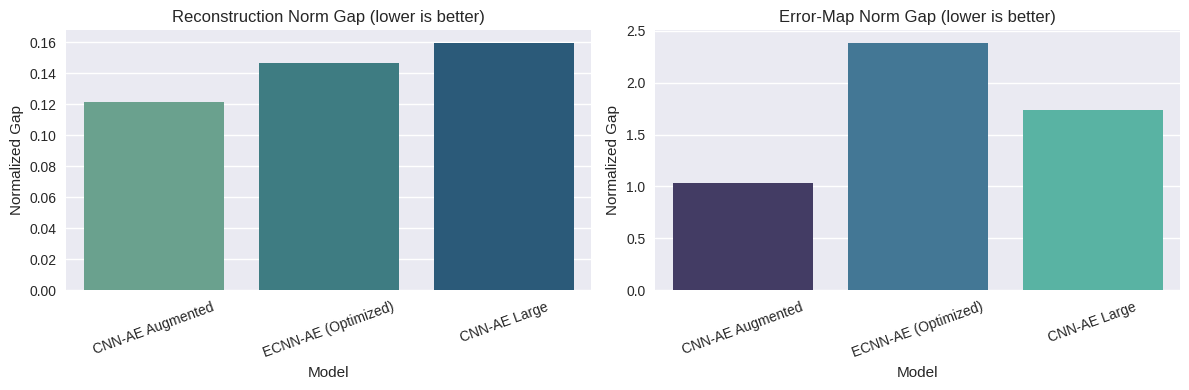

Pure equivariance test complete.


In [11]:
# Pure Equivariance Test (pre-scoring, pre-thresholding, no mask-based scoring)
# This block directly measures output consistency and error-map consistency under C4 rotations.
print('Running pure equivariance test (no scoring/thresholding)...')

pure_eq_rows = []
pure_files = normal_files + anomaly_files

for cfg in MODEL_CONFIGS:
    print(f"\n[Pure Eq] {cfg['display_name']}")
    model, ckpt_path = load_model_for_config(cfg, device)

    if 'resnet' in cfg['model_type']:
        # Not comparable in this setup for direct spatial equivariance diagnostics.
        row = {
            'model_key': cfg['key'],
            'model_name': cfg['display_name'],
            'model_type': cfg['model_type'],
            'checkpoint_path': str(ckpt_path),
            'samples_used': 0,
            'max_samples_cap': int(EQUIV_GAP_MAX_SAMPLES),
            'mean_recon_abs_gap': float('nan'),
            'mean_recon_norm_gap': float('nan'),
            'mean_error_abs_gap': float('nan'),
            'mean_error_norm_gap': float('nan'),
            'std_recon_norm_gap_k': float('nan'),
            'std_error_norm_gap_k': float('nan'),
            'diagnostic_note': 'not_applicable_in_this_setup',
        }
    else:
        metrics = compute_pure_equivariance_metrics(
            model=model,
            files=pure_files,
            device=device,
            batch_size=TARGET_BATCH_SIZE,
            max_samples=EQUIV_GAP_MAX_SAMPLES,
        )
        row = {
            'model_key': cfg['key'],
            'model_name': cfg['display_name'],
            'model_type': cfg['model_type'],
            'checkpoint_path': str(ckpt_path),
            'samples_used': int(metrics['samples_used']),
            'max_samples_cap': int(EQUIV_GAP_MAX_SAMPLES),
            'mean_recon_abs_gap': float(metrics['mean_recon_abs_gap']),
            'mean_recon_norm_gap': float(metrics['mean_recon_norm_gap']),
            'mean_error_abs_gap': float(metrics['mean_error_abs_gap']),
            'mean_error_norm_gap': float(metrics['mean_error_norm_gap']),
            'std_recon_norm_gap_k': float(metrics['std_recon_norm_gap_k']),
            'std_error_norm_gap_k': float(metrics['std_error_norm_gap_k']),
            'diagnostic_note': 'ok',
        }

    pure_eq_rows.append(row)

pure_eq_df = pd.DataFrame(pure_eq_rows).sort_values('mean_recon_norm_gap', na_position='last').reset_index(drop=True)

display_cols = [
    'model_name',
    'mean_recon_norm_gap',
    'mean_error_norm_gap',
    'mean_recon_abs_gap',
    'mean_error_abs_gap',
    'std_recon_norm_gap_k',
    'std_error_norm_gap_k',
    'samples_used',
    'max_samples_cap',
    'diagnostic_note',
]
display(pure_eq_df[display_cols])

# Compact figure focused on normalized metrics for cross-model comparability
plot_df = pure_eq_df.dropna(subset=['mean_recon_norm_gap', 'mean_error_norm_gap']).copy()
if not plot_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.barplot(data=plot_df, x='model_name', y='mean_recon_norm_gap', palette='crest', ax=axes[0])
    axes[0].set_title('Reconstruction Norm Gap (lower is better)')
    axes[0].set_xlabel('Model')
    axes[0].set_ylabel('Normalized Gap')
    axes[0].tick_params(axis='x', rotation=20)

    sns.barplot(data=plot_df, x='model_name', y='mean_error_norm_gap', palette='mako', ax=axes[1])
    axes[1].set_title('Error-Map Norm Gap (lower is better)')
    axes[1].set_xlabel('Model')
    axes[1].set_ylabel('Normalized Gap')
    axes[1].tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.show()
else:
    print('No applicable models for pure equivariance plots.')

print('Pure equivariance test complete.')

In [7]:
# Main experiment: angle-wise robustness under fixed primary threshold policy
angle_rows = []
summary_rows = []

for cfg in MODEL_CONFIGS:
    print(f"\n=== Evaluating model: {cfg['display_name']} ===")

    model, ckpt_path = load_model_for_config(cfg, device)
    mode = 'resnet' if 'resnet' in cfg['model_type'] else 'grayscale'

    # Threshold is calibrated ONCE at 0 degree using normal validation data.
    normal_ds_0 = SliceDataset(normal_files, mode=mode, rot_k=0)
    normal_loader_0 = DataLoader(normal_ds_0, batch_size=TARGET_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
    normal_scores_0 = compute_errors(
        model, normal_loader_0, device,
        use_brain_mask=USE_BRAIN_MASK_FOR_SCORING,
        min_brain_pixels=MIN_BRAIN_PIXELS,
        error_mode=FIXED_ERROR_MODE,
    )
    threshold = threshold_from_normal_scores(normal_scores_0, target_fpr=TARGET_FPR)
    print(f'Calibrated threshold@0deg: {threshold:.6f}')

    model_angle_aurocs = []
    model_angle_fprs = []
    auroc_at_zero = None

    for deg, k in zip(ANGLES_DEG, ANGLES_K):
        normal_ds = SliceDataset(normal_files, mode=mode, rot_k=k)
        anomaly_ds = SliceDataset(anomaly_files, mode=mode, rot_k=k)

        normal_loader = DataLoader(normal_ds, batch_size=TARGET_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
        anomaly_loader = DataLoader(anomaly_ds, batch_size=TARGET_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

        normal_scores = compute_errors(
            model, normal_loader, device,
            use_brain_mask=USE_BRAIN_MASK_FOR_SCORING,
            min_brain_pixels=MIN_BRAIN_PIXELS,
            error_mode=FIXED_ERROR_MODE,
        )
        anomaly_scores = compute_errors(
            model, anomaly_loader, device,
            use_brain_mask=USE_BRAIN_MASK_FOR_SCORING,
            min_brain_pixels=MIN_BRAIN_PIXELS,
            error_mode=FIXED_ERROR_MODE,
        )

        y_true = np.concatenate([np.zeros(len(normal_scores), dtype=int), np.ones(len(anomaly_scores), dtype=int)])
        y_scores = np.concatenate([normal_scores, anomaly_scores])

        metrics = compute_full_metrics(y_true, y_scores, threshold)

        auroc_val = float(metrics['auroc'])
        fpr_val = float(metrics['fpr'])
        model_angle_aurocs.append(auroc_val)
        model_angle_fprs.append(fpr_val)

        if deg == 0:
            auroc_at_zero = auroc_val

        angle_rows.append({
            'model_key': cfg['key'],
            'model_name': cfg['display_name'],
            'model_type': cfg['model_type'],
            'checkpoint_path': str(ckpt_path),
            'rotation_deg': int(deg),
            'rotation_k': int(k),
            'score_method': TARGET_SCORE_METHOD,
            'threshold_method': 'fpr',
            'target_fpr': float(TARGET_FPR),
            'calibrated_at_deg': 0,
            'threshold': float(threshold),
            'error_mode': FIXED_ERROR_MODE,
            'use_brain_mask_for_scoring': bool(USE_BRAIN_MASK_FOR_SCORING),
            'min_brain_pixels': int(MIN_BRAIN_PIXELS),
            'accuracy': float(metrics['accuracy']),
            'precision': float(metrics['precision']),
            'recall': float(metrics['recall']),
            'specificity': float(metrics['specificity']),
            'f1_score': float(metrics['f1_score']),
            'auroc': auroc_val,
            'auprc': float(metrics['auprc']),
            'fpr_realized': fpr_val,
            'fnr': float(metrics['fnr']),
            'normal_count': int(len(normal_scores)),
            'anomaly_count': int(len(anomaly_scores)),
        })

        print(f"  Angle {deg:>3} deg | AUROC={auroc_val:.4f} | Realized FPR={fpr_val:.4f}")

    mean_auroc = float(np.mean(model_angle_aurocs))
    std_auroc = float(np.std(model_angle_aurocs))
    min_auroc = float(np.min(model_angle_aurocs))
    max_drop = float((auroc_at_zero if auroc_at_zero is not None else model_angle_aurocs[0]) - min_auroc)
    mean_fpr_dev = float(np.mean(np.abs(np.asarray(model_angle_fprs) - TARGET_FPR)))

    # Equivariance gap is computed directly only for grayscale models (shape-consistent rotation space).
    if 'resnet' in cfg['model_type']:
        equiv_gap = float('nan')
    else:
        merged_files = normal_files + anomaly_files
        equiv_gap = compute_equivariance_gap(
            model=model,
            files=merged_files,
            device=device,
            batch_size=TARGET_BATCH_SIZE,
            max_samples=EQUIV_GAP_MAX_SAMPLES,
        )

    summary_rows.append({
        'model_key': cfg['key'],
        'model_name': cfg['display_name'],
        'model_type': cfg['model_type'],
        'checkpoint_path': str(ckpt_path),
        'mean_auroc_over_angles': mean_auroc,
        'std_auroc_over_angles': std_auroc,
        'max_auroc_drop_from_0deg': max_drop,
        'mean_abs_fpr_deviation': mean_fpr_dev,
        'equivariance_gap_c4': equiv_gap,
        'angles_evaluated': str(ANGLES_DEG),
        'target_fpr': float(TARGET_FPR),
        'score_method': TARGET_SCORE_METHOD,
        'threshold_policy': 'fixed threshold calibrated at 0deg normals',
    })

    print(f"Summary -> mean AUROC={mean_auroc:.4f}, std={std_auroc:.4f}, max drop={max_drop:.4f}, mean |FPR-0.2|={mean_fpr_dev:.4f}, eq-gap={equiv_gap:.6f}")

print('\nExperiment run complete.')


=== Evaluating model: ECNN-AE (Optimized) ===
Using direct checkpoint path from config: /content/drive/MyDrive/symAD-ECNN/models/saved_models/ecnn_optimized/ecnn_optimized_best.pth
Detected ECNNAutoencoderV3 checkpoint. Using latent_dim=1024.


/usr/local/lib/python3.12/dist-packages/e2cnn/nn/modules/r2_conv/basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:37.)
  full_mask[mask] = norms.to(torch.uint8)


Model weights loaded from: /content/drive/MyDrive/symAD-ECNN/models/saved_models/ecnn_optimized/ecnn_optimized_best.pth


Computing reconstruction errors:   0%|          | 0/229 [00:00<?, ?it/s]

Calibrated threshold@0deg: 0.010824


...

Computing reconstruction errors:   0%|          | 0/488 [00:00<?, ?it/s]

  Angle 180 deg | AUROC=0.7660 | Realized FPR=0.1936


Computing reconstruction errors:   0%|          | 0/229 [00:00<?, ?it/s]

Computing reconstruction errors:   0%|          | 0/488 [00:00<?, ?it/s]

  Angle 270 deg | AUROC=0.5878 | Realized FPR=0.5197
Summary -> mean AUROC=0.6797, std=0.0925, max drop=0.1913, mean |FPR-0.2|=0.1574, eq-gap=0.120814

Experiment run complete.


In [8]:
# Consolidated result table (thesis-ready)
if not angle_rows or not summary_rows:
    raise RuntimeError('No experiment results found. Run the main experiment cell first.')

angle_df = pd.DataFrame(angle_rows)
summary_df = pd.DataFrame(summary_rows)

summary_df = summary_df.sort_values([
    'mean_auroc_over_angles',
    'std_auroc_over_angles',
], ascending=[False, True]).reset_index(drop=True)

display_cols = [
    'model_name',
    'mean_auroc_over_angles',
    'std_auroc_over_angles',
    'max_auroc_drop_from_0deg',
    'mean_abs_fpr_deviation',
    'equivariance_gap_c4',
]
display(summary_df[display_cols])

angle_csv = TABLE_DIR / 'equivariance_anglewise_metrics.csv'
summary_csv = TABLE_DIR / 'equivariance_consolidated_summary.csv'
summary_md = TABLE_DIR / 'equivariance_consolidated_summary.md'
angle_json = JSON_DIR / 'equivariance_anglewise_metrics.json'
summary_json = JSON_DIR / 'equivariance_consolidated_summary.json'

angle_df.to_csv(angle_csv, index=False)
summary_df.to_csv(summary_csv, index=False)
summary_df.to_markdown(summary_md, index=False)

with open(angle_json, 'w', encoding='utf-8') as f:
    json.dump(angle_rows, f, indent=2)
with open(summary_json, 'w', encoding='utf-8') as f:
    json.dump(summary_rows, f, indent=2)

print(f'Angle-wise CSV saved: {angle_csv}')
print(f'Consolidated CSV saved: {summary_csv}')
print(f'Consolidated Markdown saved: {summary_md}')
print(f'Angle-wise JSON saved: {angle_json}')
print(f'Consolidated JSON saved: {summary_json}')

,model_name,mean_auroc_over_angles,std_auroc_over_angles,max_auroc_drop_from_0deg,mean_abs_fpr_deviation,equivariance_gap_c4
0,CNN-AE Augmented,0.679686,0.092462,0.191320,0.157393,0.120814
1,CNN-AE Large,0.674843,0.108682,0.269934,0.397275,0.159464
2,ECNN-AE (Optimized),0.650151,0.143636,0.349000,0.468469,0.145590


Angle-wise CSV saved: /content/drive/MyDrive/symAD-ECNN/evaluations/tables/equivariance_effect_primary_style/equivariance_anglewise_metrics.csv
Consolidated CSV saved: /content/drive/MyDrive/symAD-ECNN/evaluations/tables/equivariance_effect_primary_style/equivariance_consolidated_summary.csv
Consolidated Markdown saved: /content/drive/MyDrive/symAD-ECNN/evaluations/tables/equivariance_effect_primary_style/equivariance_consolidated_summary.md
Angle-wise JSON saved: /content/drive/MyDrive/symAD-ECNN/evaluations/json/equivariance_effect_primary_style/equivariance_anglewise_metrics.json
Consolidated JSON saved: /content/drive/MyDrive/symAD-ECNN/evaluations/json/equivariance_effect_primary_style/equivariance_consolidated_summary.json


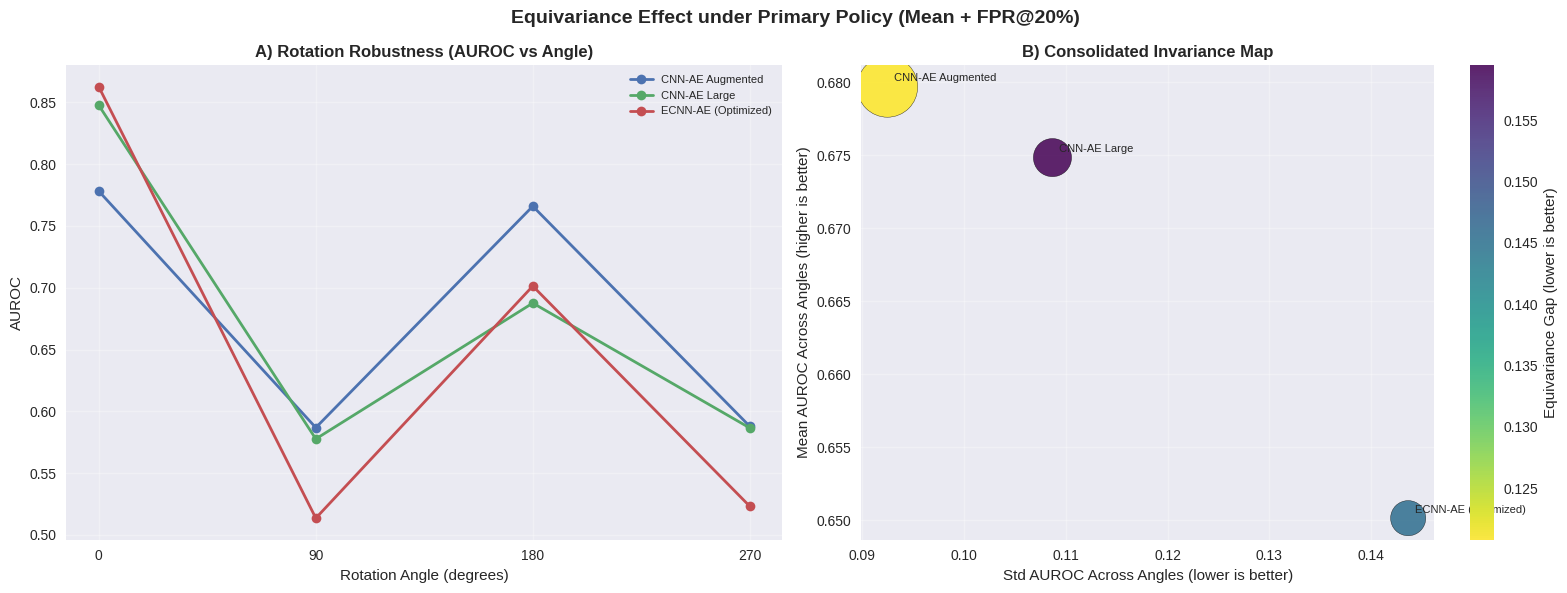

Consolidated figure saved: /content/drive/MyDrive/symAD-ECNN/evaluations/figures/equivariance_effect_primary_style/equivariance_effect_consolidated_figure.png


In [9]:
# One consolidated thesis figure (single figure, 2 panels)
if 'angle_df' not in globals() or 'summary_df' not in globals():
    raise RuntimeError('Run consolidation cell first.')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: AUROC vs rotation angle
for model_name, g in angle_df.groupby('model_name'):
    g = g.sort_values('rotation_deg')
    axes[0].plot(g['rotation_deg'], g['auroc'], marker='o', linewidth=2, label=model_name)

axes[0].set_title('A) Rotation Robustness (AUROC vs Angle)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rotation Angle (degrees)')
axes[0].set_ylabel('AUROC')
axes[0].set_xticks(ANGLES_DEG)
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8, loc='best')

# Panel B: Consolidated invariance summary
plot_df = summary_df.copy()
plot_df['std_rank_inv'] = 1.0 / (plot_df['std_auroc_over_angles'] + 1e-6)

sc = axes[1].scatter(
    plot_df['std_auroc_over_angles'],
    plot_df['mean_auroc_over_angles'],
    s=300 * (1.0 / (plot_df['mean_abs_fpr_deviation'] + 1e-4)),
    c=plot_df['equivariance_gap_c4'].fillna(plot_df['equivariance_gap_c4'].max(skipna=True) if plot_df['equivariance_gap_c4'].notna().any() else 0.0),
    cmap='viridis_r',
    alpha=0.85,
    edgecolors='black',
)

for _, r in plot_df.iterrows():
    axes[1].annotate(r['model_name'], (r['std_auroc_over_angles'], r['mean_auroc_over_angles']), fontsize=8, xytext=(5, 4), textcoords='offset points')

axes[1].set_title('B) Consolidated Invariance Map', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Std AUROC Across Angles (lower is better)')
axes[1].set_ylabel('Mean AUROC Across Angles (higher is better)')
axes[1].grid(alpha=0.3)
cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_label('Equivariance Gap (lower is better)')

fig.suptitle('Equivariance Effect under Primary Policy (Mean + FPR@20%)', fontsize=14, fontweight='bold')
plt.tight_layout()

fig_path = FIG_DIR / 'equivariance_effect_consolidated_figure.png'
plt.savefig(fig_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'Consolidated figure saved: {fig_path}')

## Done
This notebook provides a primary-style, controlled equivariance experiment with:
- fixed threshold policy at FPR 20%
- angle-wise robustness metrics
- one consolidated thesis table
- one consolidated thesis figure
- one auto-generated thesis paragraph